In [ ]:
import os
import tensorflow as tf
from PIL import Image

# 1. Download Fashion-MNIST directly from TensorFlow
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 2. Create the main folder your code is looking for
base_dir = "fashion_mnist_images"

# 3. Save training images into subfolders (0 through 9)
for idx, (img, label) in enumerate(zip(x_train, y_train)):
    # Create the class subfolder if it doesn't exist (e.g., fashion_mnist_images/0)
    label_dir = os.path.join(base_dir, str(label))
    os.makedirs(label_dir, exist_ok=True)
    
    # Save the array as a PNG image
    img_pil = Image.fromarray(img)
    img_pil.save(os.path.join(label_dir, f"train_{idx}.png"))

print(f"Done! The '{base_dir}' folder is ready for your code.")

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
# 1. Set paths & hyperparameters
train_dir = "/home/dale_pablo/fashion_mnist_images"  #WSL Linux filesystem and used its absolute path so TensorFlow could access the image files directly within Linux.
# Alternatively if uour using native windows then you directly specify train_dir="fashion_mnist_images"
image_size = (28, 28)
batch_size = 32
epochs = 10
# 2. Create ImageDataGenerator for training & validation
datagen = ImageDataGenerator(
rescale=1/255.0, #Normalization 0-1
validation_split=0.2
)
train_generator = datagen.flow_from_directory( #Gets into the folders then finds the images
train_dir,
target_size=image_size,
batch_size=batch_size,
color_mode='grayscale',
class_mode='categorical',
subset='training'
)

#20% validation
val_generator = datagen.flow_from_directory(
train_dir,
target_size=image_size,
batch_size=batch_size,
color_mode='grayscale',
class_mode='categorical',
subset='validation'
)

1

# 3. Build the CNN model
model = models.Sequential([
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), #32 filters that slides over the image 
#Output Imagesize-kernel+1 i.e 28-3+1=26
layers.MaxPooling2D((2, 2)),   #Reduces the Image dimesnsion for efficient computation
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),   #1 D vector
layers.Dense(128, activation='relu'),
layers.Dense(train_generator.num_classes, activation='softmax')
])
# 4. Compile the model
model.compile(optimizer='adam',

loss='categorical_crossentropy',
metrics=['accuracy'])

# 5. Train the model
history = model.fit(
train_generator,
epochs=epochs,
validation_data=val_generator
)
# 6. Save model & history
model.save("fashion_mnist_cnn.h5")



I0000 00:00:1791180147.030473    5399 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 30796 images belonging to 10 classes.
Found 7692 images belonging to 10 classes.


/mnt/c/Users/Dale Menezes/Desktop/Computer-Vision/tf-env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1791180242.134494    5399 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/10


I0000 00:00:1791180246.449516    5399 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1791180248.009431    5598 service.cc:153] XLA service 0x79dbdc032670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791180248.009503    5598 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791180248.234937    5598 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791180248.884696    5598 cuda_dnn.cc:461] Loaded cuDNN version 92700
I0000 00:00:1791180248.962731    5598 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1658__.34


  5/963 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.1875 - loss: 2.2081

I0000 00:00:1791180269.693363    5598 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


673/963 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7843 - loss: 0.5948

I0000 00:00:1791180278.417850    5598 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1658__.34


963/963 ━━━━━━━━━━━━━━━━━━━━ 50s 28ms/step - accuracy: 0.8059 - loss: 0.5407 - val_accuracy: 0.8540 - val_loss: 0.3924
Epoch 2/10
963/963 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8712 - loss: 0.3545 - val_accuracy: 0.8771 - val_loss: 0.3422
Epoch 3/10
963/963 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8911 - loss: 0.3026 - val_accuracy: 0.8904 - val_loss: 0.3029
Epoch 4/10
963/963 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9025 - loss: 0.2681 - val_accuracy: 0.8881 - val_loss: 0.3041
Epoch 5/10
963/963 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9113 - loss: 0.2431 - val_accuracy: 0.8937 - val_loss: 0.2955
Epoch 6/10
963/963 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9203 - loss: 0.2175 - val_accuracy: 0.9030 - val_loss: 0.2810
Epoch 7/10
963/963 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9276 - loss: 0.1924 - val_accuracy: 0.9028 - val_loss: 0.2757
Epoch 8/10
963/963 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9344 - loss: 0.1733 - val_accurac

In [6]:
import random
# 7. Make predictions
x_batch, y_batch = next(val_generator) # next batch
#x_batch contains 32 images and y_batch contains labels
ind = random.randint(0,31)  #choose random image from 32 images
img = x_batch[ind]
true_label = np.argmax(y_batch[ind])  #labels are stored in one-hot encoding ex: ([0,0,1,0,0,0,0,0,0])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


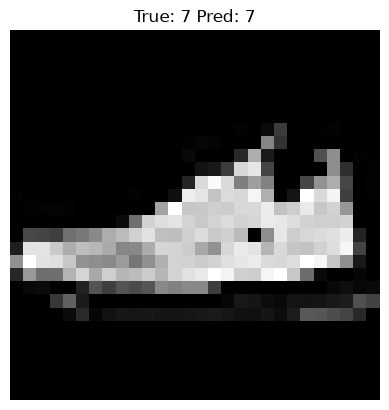

In [7]:
# 8. Run prediction
#img has 28*28*1
# CNN expects image in batch

pred = model.predict(np.expand_dims(img, axis=0)) #expand_dims add one extra dimesnion which is '1' since one image 1*28*28*1
pred_label = np.argmax(pred) #selects the highest value


# 9. Display results
plt.imshow(img.squeeze(), cmap="gray")  #squeeeze removes the unnecessary dimension which is '1' whcih we dont need for displaying
plt.title(f"True: {list(train_generator.class_indices.keys())[true_label]} Pred: {list(train_generator.class_indices.keys())[pred_label]}")
plt.axis("off")
plt.show()